# OPUS Books EN-NL data analysis

Some data analysis for deciding pre-processing steps and architectuer choices for my encoder-decoder tranlsation transformer

In [1]:
from pathlib import Path
import sys

p = Path.cwd()

while p != p.parent and not (p / "src").exists():
    p = p.parent
# Add the project root (parent of `src`) so `src` is importable as a top-level package
sys.path.insert(0, str(p))

In [2]:
from datasets import load_dataset, Dataset  # type: ignore
from typing import Dict, Any, Tuple
from torch.utils.data import random_split, Subset

from src.tokenizer import CustomTokenizer
from src.constants import END_TOKEN, PAD_TOKEN, START_TOKEN, UNKNOWN_TOKEN


def get_max_sequence_length(
    dataset: Subset,
    source_tokenizer: CustomTokenizer,
    target_tokenizer: CustomTokenizer,
) -> Tuple[int, int]:
    """Determines the maximum sequence length for source and target sentences in the dataset.

    Args:
        dataset: The dataset containing the sentences.
        source_tokenizer (CustomTokenizer): The tokenizer for the source language.
        target_tokenizer (CustomTokenizer): The tokenizer for the target language.

    Returns:
        Tuple[int, int]: A tuple containing the maximum source and target sequence lengths respectively.
    """
    max_source_length = 0
    max_target_length = 0

    for item in dataset:  # type: ignore
        source_length = len(source_tokenizer.encode(item["translation"]["en"]))  # type: ignore
        target_length = len(target_tokenizer.encode(item["translation"]["nl"]))  # type: ignore

        max_source_length = max(max_source_length, source_length)
        max_target_length = max(max_target_length, target_length)

    # Return the maximum of source and target lengths
    return max_source_length, max_target_length


def get_sentences_from_data(dataset) -> tuple[object, list[str], list[str]]:
    """Loads the OPUS Books dataset for English to Dutch translation."""
    # Load the dataset
    dataset = load_dataset("opus_books", "en-nl", split="train")

    source_sentences: list[str] = []
    target_sentences: list[str] = []

    # Iterate through the dataset and extract the English and Dutch translations
    # Each item has a "translation" field with a dictionary containing "en" and "nl" key-translations
    for item in dataset:
        # Access the translation fields directly from the item
        source_sentences.append(item["translation"]["en"])  # type: ignore
        target_sentences.append(item["translation"]["nl"])  # type: ignore
    return dataset, source_sentences, target_sentences


def load_opus_data(train_split: float = 0.7, val_split: float = 0.15, test_split: float = 0.15, deterministic: bool = False):
    """Get a train-validation-test split of the OPUS Books dataset for English to Dutch translation.

    Args:
        train_split (float, optional): The percentage of the dataset to use for training. Defaults to 0.7.
        val_split (float, optional): The percentage of the dataset to use for validation. Defaults to 0.15.
        test_split (float, optional): The percentage of the dataset to use for testing. Defaults to 0.15.
        deterministic (bool, optional): Whether to use a fixed seed for reproducibility. Defaults to False.

    Returns:
        Tuple containing (train_data, val_data, test_data)
    """
    # Validate that splits sum to 1.0
    total_split = train_split + val_split + test_split
    if not (0.99 <= total_split <= 1.01):  # Allow small floating point errors
        raise ValueError(f"Train, validation, and test splits must sum to 1.0, got {total_split}")

    # Load the dataset
    dataset_nl: Dataset = load_dataset("wikimedia/wikipedia", "20231101.nl", split="train")  # type: ignore
    dataset_en: Dataset = load_dataset("wikimedia/wikipedia", "20231101.en", split="train")  # type: ignore

    seed = 42 if deterministic else None  # Use a fixed seed for reproducibility
    # combine into pairs
    dataset = Dataset.from_dict({
        "translation": [
            {"en": en_item, "nl": nl_item}
            for en_item, nl_item in zip(dataset_en, dataset_nl)
        ]
    })
    dataset = dataset.shuffle(seed=seed)  # type: ignore
    # Calculate the sizes for training, validation, and test sets
    dataset_length = len(dataset)  # type: ignore
    train_size = int(dataset_length * train_split)
    val_size = int(dataset_length * val_split)
    test_size = dataset_length - train_size - val_size

    train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])  # type: ignore

    return train_data, val_data, test_data


d:\conda-envs\transformers-from-scratch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load parallel corpus into lists
src_path = "../../../data/wikimedia.en-nl.en"
tgt_path = "../../../data/wikimedia.en-nl.nl"

with open(src_path, "r", encoding="utf-8") as f:
    source_sentences = [line.rstrip("\n") for line in f]

with open(tgt_path, "r", encoding="utf-8") as f:
    target_sentences = [line.rstrip("\n") for line in f]

# Basic sanity check and a few examples
if len(source_sentences) != len(target_sentences):
    raise ValueError(f"Mismatched pair counts: {len(source_sentences)} vs {len(target_sentences)}")

print(f"Loaded {len(source_sentences)} sentence pairs")
for i in range(min(3, len(source_sentences))):
    print(f"\nPair {i} — SOURCE:\n{source_sentences[i]}\nTARGET:\n{target_sentences[i]}")

# Combine into a dataset
dataset = Dataset.from_dict({
    "translation": [
        {"en": src, "nl": tgt}
        for src, tgt in zip(source_sentences, target_sentences)
    ]
})

train, val, test = random_split(dataset, [0.7, 0.15, 0.15])  # type: ignore

Loaded 111760 sentence pairs

Pair 0 — SOURCE:
Lea Rue is the stage name of Emma Lauwers, a Belgian singer. 
TARGET:
Lea Rue, artiestennaam van Emma Lauwers is een Belgische zangeres. 

Pair 1 — SOURCE:
Life and career 
TARGET:
Levensloop en carrière 

Pair 2 — SOURCE:
Lauwers began her singing career on The Voice van Vlaanderen, where she was coached by Axelle Red. 
TARGET:
Lauwers begon haar zangcarrière in The Voice van Vlaanderen, waar ze gecoacht werd door Axelle Red. In 2015 scoorde ze een hit met I Can't Say No!. De single kwam op 25 juli binnen in de Ultratop 50. 


In [4]:
# Check for duplicates
seen_sentences = set()
duplicates = 0
for item in train:  # type: ignore
    source_sentence = item["translation"]["en"]  # type: ignore
    target_sentence = item["translation"]["nl"]  # type: ignore
    sentence_pair = (source_sentence, target_sentence)
    if sentence_pair in seen_sentences:
        duplicates += 1
    else:
        seen_sentences.add(sentence_pair)

print(f"Number of duplicate sentence pairs in training set: {duplicates}")

Number of duplicate sentence pairs in training set: 3282


In [5]:
dutch_sentences = [item["translation"]["nl"] for item in train]  # type: ignore
english_sentences = [item["translation"]["en"] for item in train]  # type: ignore
sentences = [*english_sentences, *dutch_sentences]

tokenizer = CustomTokenizer("opus_tokenizer")
tokenizer.train(sentences)
tokenizer.save("../../../models/tokenizers/opus_tokenizer.json")

tokenizer.print_tokens(english_sentences[0])
tokenizer.print_tokens(dutch_sentences[0])

# Vocab size
print(f"Tokenizer vocabulary size: {tokenizer.vocabulary_size}")

Tokenizer file not found at opus_tokenizer. Initializing a new tokenizer.
Tokenizer saved to ../../../models/tokenizers/opus_tokenizer.json
Original text: References 
Tokens: ['References']
Token IDs: [5128]
Original text: Referenties 
Tokens: ['Referenties']
Token IDs: [6212]
Tokenizer vocabulary size: 30000


In [6]:
from collections import Counter

tokenized_sentences = [tokenizer.encode(sentence) for sentence in sentences]
all_tokens = sorted([token for sentence in tokenized_sentences for token in sentence])

counter = Counter(all_tokens)
most_common_tokens = counter.most_common(10)

print("Most common tokens and their frequencies:")
for token, freq in most_common_tokens:
    print(f"Token: {tokenizer.decode([token])}, Token ID: {token}, Frequency: {freq}")

Most common tokens and their frequencies:
Token: ,, Token ID: 15, Frequency: 198219
Token: ., Token ID: 17, Frequency: 161036
Token: the, Token ID: 2756, Frequency: 104052
Token: in, Token ID: 2744, Frequency: 96144
Token: de, Token ID: 2748, Frequency: 92135
Token: of, Token ID: 2764, Frequency: 71496
Token: -, Token ID: 16, Frequency: 70196
Token: van, Token ID: 2769, Frequency: 64375
Token: ], Token ID: 64, Frequency: 59209
Token: and, Token ID: 2760, Frequency: 55612


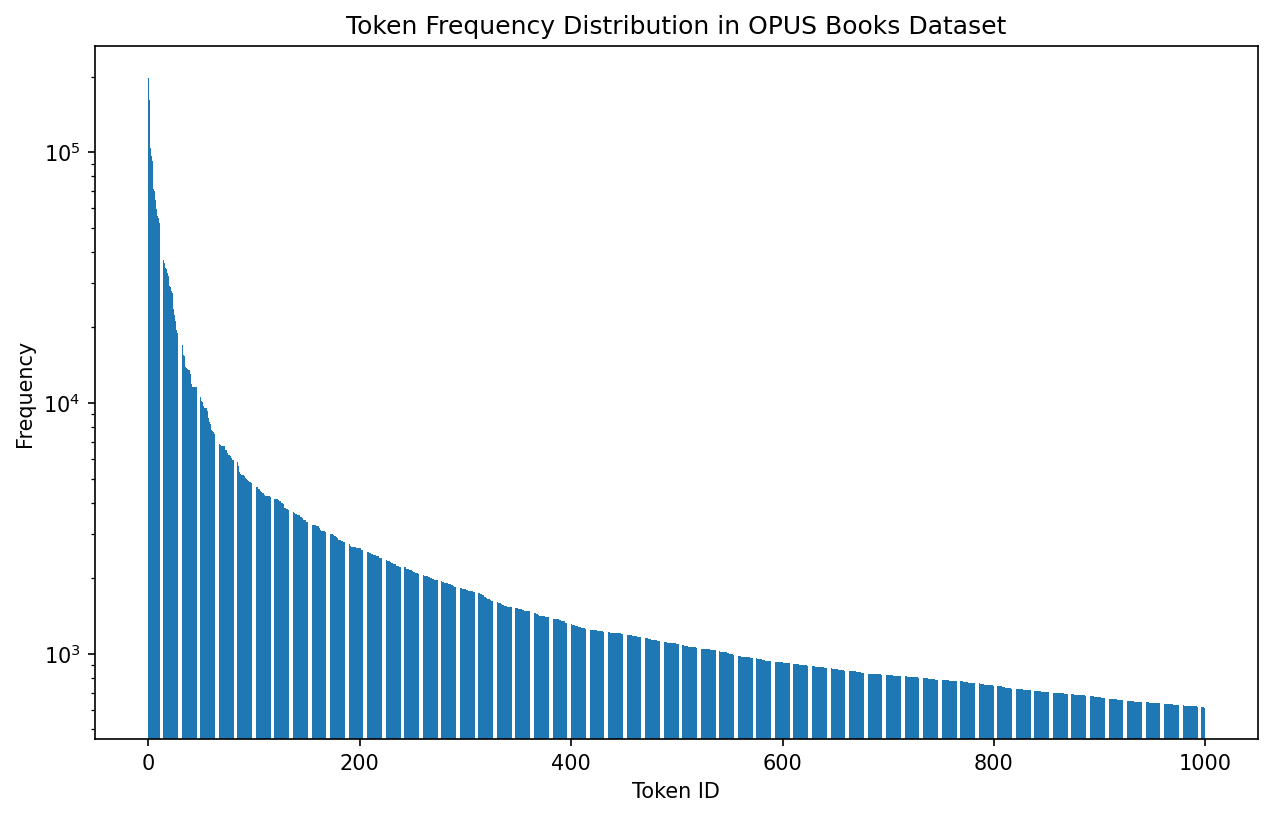

In [7]:
import matplotlib.pyplot as plt
# Plot token frequency in sentences
plt.figure(figsize=(10, 6), dpi=150)
plt.bar([i for i in range(1000)], [x[1] for x in counter.most_common(1000)])
plt.title("Token Frequency Distribution in OPUS Books Dataset")
plt.xlabel("Token ID")
plt.ylabel("Frequency")
plt.yscale("log")
plt.show()

## Source vs. Target Sentence Lengths in Tokens

Number of Dutch sentences: 78232
Number of English sentences: 78232
Maximum Dutch sentence length (in tokens): 2868
Maximum English sentence length (in tokens): 2868
Minimum Dutch sentence length (in tokens): 1
Minimum English sentence length (in tokens): 1
Average Dutch sentence length (in tokens): 35.91
Average English sentence length (in tokens): 37.00
90th percentile Dutch sentence length (in tokens): 71
90th percentile English sentence length (in tokens): 74
95th percentile Dutch sentence length (in tokens): 96
95th percentile English sentence length (in tokens): 101


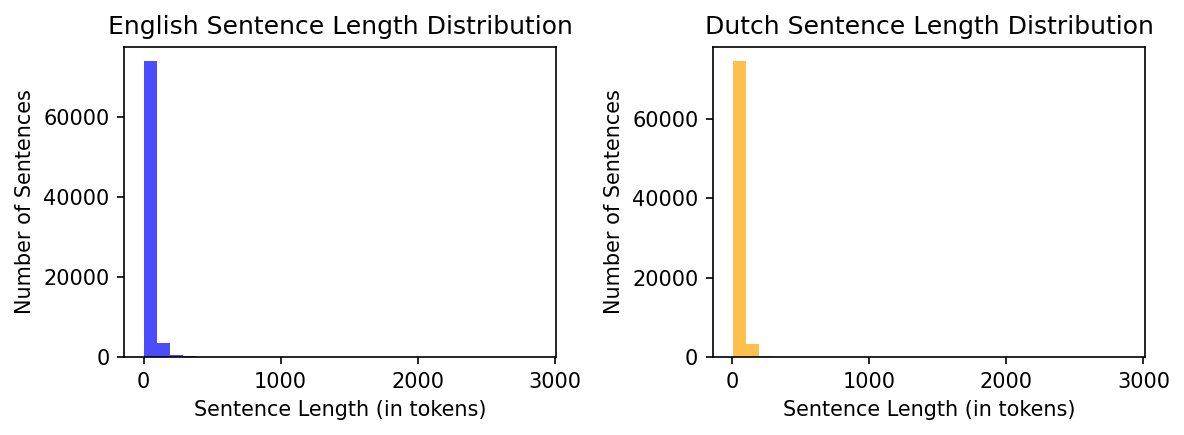

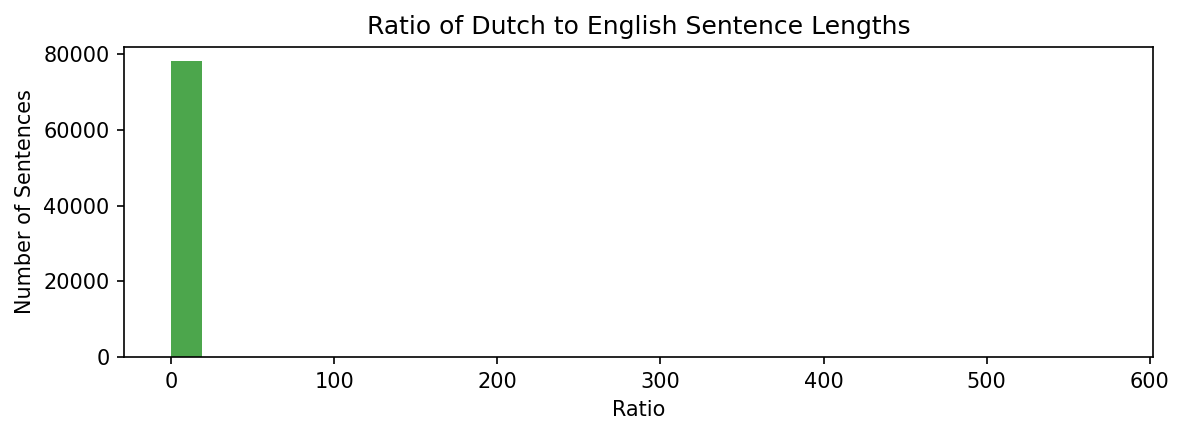

Minimum Dutch to English length ratio: 0.00
Maximum Dutch to English length ratio: 573.00
Average Dutch to English length ratio: 1.16
90th percentile Dutch to English length ratio: 1.33
95th percentile Dutch to English length ratio: 1.72


In [8]:
# Both lists are in same order
tokenized_dutch = [tokenizer.encode(sentence) for sentence in dutch_sentences]
tokenized_english = [tokenizer.encode(sentence) for sentence in english_sentences]

max_dutch_length = max(len(sentence) for sentence in tokenized_dutch)
max_english_length = max(len(sentence) for sentence in tokenized_english)
min_dutch_length = min(len(sentence) for sentence in tokenized_dutch)
min_english_length = min(len(sentence) for sentence in tokenized_english)

print(f"Number of Dutch sentences: {len(tokenized_dutch)}")
print(f"Number of English sentences: {len(tokenized_english)}")
tokenized_pairs = list(zip(tokenized_english, tokenized_dutch))

print(f"Maximum Dutch sentence length (in tokens): {max_dutch_length}")
print(f"Maximum English sentence length (in tokens): {max_english_length}")
print(f"Minimum Dutch sentence length (in tokens): {min_dutch_length}")
print(f"Minimum English sentence length (in tokens): {min_english_length}")

# Two subplots next to each other showing distribution of sentence lengths per language
avg_dutch_length = sum(len(sentence) for sentence in tokenized_dutch) / len(tokenized_dutch)
avg_english_length = sum(len(sentence) for sentence in tokenized_english) / len(tokenized_english)
print(f"Average Dutch sentence length (in tokens): {avg_dutch_length:.2f}")
print(f"Average English sentence length (in tokens): {avg_english_length:.2f}")
p90_dutch_length = sorted(len(sentence) for sentence in tokenized_dutch)[int(0.9 * len(tokenized_dutch))]
p90_english_length = sorted(len(sentence) for sentence in tokenized_english)[int(0.9 * len(tokenized_english))]
print(f"90th percentile Dutch sentence length (in tokens): {p90_dutch_length}")
print(f"90th percentile English sentence length (in tokens): {p90_english_length}")
p95_dutch_length = sorted(len(sentence) for sentence in tokenized_dutch)[int(0.95 * len(tokenized_dutch))]
p95_english_length = sorted(len(sentence) for sentence in tokenized_english)[int(0.95 * len(tokenized_english))]
print(f"95th percentile Dutch sentence length (in tokens): {p95_dutch_length}")
print(f"95th percentile English sentence length (in tokens): {p95_english_length}")


plt.figure(figsize=(8, 3), dpi=150)
plt.subplot(1, 2, 1)
plt.hist([len(sentence) for sentence in tokenized_english], bins=30, color='blue', alpha=0.7)
plt.title("English Sentence Length Distribution")
plt.xlabel("Sentence Length (in tokens)")
plt.ylabel("Number of Sentences")
plt.subplot(1, 2, 2)
plt.hist([len(sentence) for sentence in tokenized_dutch], bins=30, color='orange', alpha=0.7)
plt.title("Dutch Sentence Length Distribution")
plt.xlabel("Sentence Length (in tokens)")
plt.ylabel("Number of Sentences")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3), dpi=150)
# Plot ratio of Dutch to English sentence lengths
length_ratios = [len(dutch) / len(english) if len(english) > 0 else 0 for english, dutch in tokenized_pairs]
plt.hist(length_ratios, bins=30, color='green', alpha=0.7)
plt.title("Ratio of Dutch to English Sentence Lengths")
plt.xlabel("Ratio")
plt.ylabel("Number of Sentences")
plt.tight_layout()
plt.show()

min_ratio = min(length_ratios)
max_ratio = max(length_ratios)
avg_ratio = sum(length_ratios) / len(length_ratios)
p90_ratio = sorted(length_ratios)[int(0.9 * len(length_ratios))]
p95_ratio = sorted(length_ratios)[int(0.95 * len(length_ratios))]
print(f"Minimum Dutch to English length ratio: {min_ratio:.2f}")
print(f"Maximum Dutch to English length ratio: {max_ratio:.2f}")
print(f"Average Dutch to English length ratio: {avg_ratio:.2f}")
print(f"90th percentile Dutch to English length ratio: {p90_ratio:.2f}")
print(f"95th percentile Dutch to English length ratio: {p95_ratio:.2f}")

# Vocab coverage on test and validation sets

In [9]:
# Tokenize all sentences
tokenized_dutch_validation = [tokenizer.encode(item["translation"]["nl"]) for item in val]  # type: ignore
tokenized_english_validation = [tokenizer.encode(item["translation"]["en"]) for item in val]  # type: ignore
tokenized_dutch_test = [tokenizer.encode(item["translation"]["nl"]) for item in test]  # type: ignore
tokenized_english_test = [tokenizer.encode(item["translation"]["en"]) for item in test]  # type: ignore

# Check percentage of <UNK> tokens in validation and test sets
def calculate_unk_percentage(tokenized_sentences: list[list[int]], unk_token_id: int) -> float:
    total_tokens = sum(len(sentence) for sentence in tokenized_sentences)
    unk_tokens = sum(sentence.count(unk_token_id) for sentence in tokenized_sentences)
    return (unk_tokens / total_tokens) * 100 if total_tokens > 0 else 0.0

unk_token_id = tokenizer.token_to_id(UNKNOWN_TOKEN)
val_unk_percentage_english = calculate_unk_percentage(tokenized_english_validation, unk_token_id)
val_unk_percentage_dutch = calculate_unk_percentage(tokenized_dutch_validation, unk_token_id)
test_unk_percentage_english = calculate_unk_percentage(tokenized_english_test, unk_token_id)
test_unk_percentage_dutch = calculate_unk_percentage(tokenized_dutch_test, unk_token_id)
print(f"Validation set <UNK> token percentage (English): {val_unk_percentage_english:.4f}%")
print(f"Validation set <UNK> token percentage (Dutch): {val_unk_percentage_dutch:.4f}%")
print(f"Test set <UNK> token percentage (English): {test_unk_percentage_english:.4f}%")
print(f"Test set <UNK> token percentage (Dutch): {test_unk_percentage_dutch:.4f}%")

Validation set <UNK> token percentage (English): 0.0391%
Validation set <UNK> token percentage (Dutch): 0.0252%
Test set <UNK> token percentage (English): 0.0599%
Test set <UNK> token percentage (Dutch): 0.0650%


# Weird sentences

In [10]:
# There are a lot with DOI references, check some examples
counter = 0
for i, item in enumerate(train):  # type: ignore
    source_sentence = item["translation"]["en"]  # type: ignore
    target_sentence = item["translation"]["nl"]  # type: ignore
    doi_token_id = tokenizer.token_to_id("DOI")
    tokenized_source = tokenizer.encode(source_sentence)
    tokenized_target = tokenizer.encode(target_sentence)
    if doi_token_id in tokenized_source or doi_token_id in tokenized_target:
        counter += 1
        print(f"\nExample with DOI token in validation set (index {i}):")
        print(f"SOURCE: {source_sentence}")
        print(f"TOKENS: {tokenized_source}")
        print(f"PARSED TOKENS: {[tokenizer.decode([token]) for token in tokenized_source]}")
        print(f"TARGET: {target_sentence}")
        print(f"TOKENS: {tokenized_target}")
        print(f"PARSED TOKENS: {[tokenizer.decode([token]) for token in tokenized_target]}")

print(f"Total examples with DOI token in validation set: {counter}")


Example with DOI token in validation set (index 385):
SOURCE: 3: 52. doi:10.1177/2053019615609953. ↑ "About George Perkins Marsh". http://americanhistory.si.edu/. 
TOKENS: [22, 29, 5548, 17, 6333, 29, 2943, 17, 28825, 18, 17741, 3192, 3100, 25798, 4863, 5689, 17, 1010, 5, 8230, 4983, 28066, 7445, 3009, 5495, 4756, 4399, 10493, 5134, 17, 5466, 17, 16082, 24692]
PARSED TOKENS: ['3', ':', '52', '.', 'doi', ':', '10', '.', '1177', '/', '205', '30', '196', '1560', '99', '53', '.', '↑', '"', 'About', 'George', 'Perkins', 'Marsh', '".', 'http', '://', 'amer', 'ican', 'history', '.', 'si', '.', 'edu', '/.']
TARGET: DOI: 10.1177/2053019615609953. ↑ About George Perkins Marsh. 
TOKENS: [7708, 29, 2943, 17, 28825, 18, 17741, 3192, 3100, 25798, 4863, 5689, 17, 1010, 8230, 4983, 28066, 7445, 17]
PARSED TOKENS: ['DOI', ':', '10', '.', '1177', '/', '205', '30', '196', '1560', '99', '53', '.', '↑', 'About', 'George', 'Perkins', 'Marsh', '.']

Example with DOI token in validation set (index 876):
SOUR

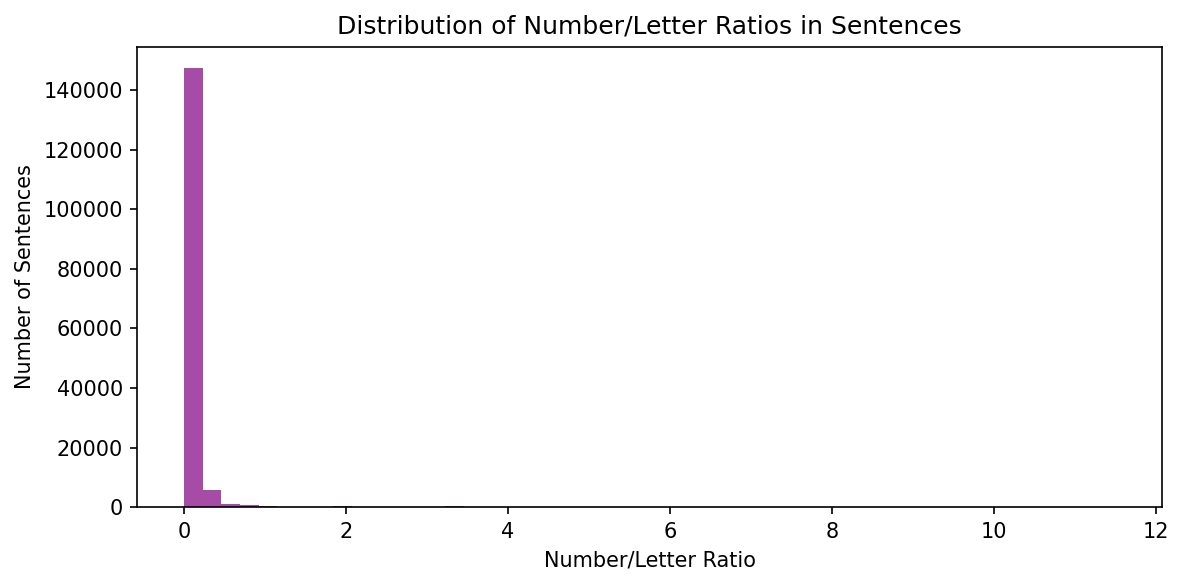

Minimum number/letter ratio: 0.0000
Maximum number/letter ratio: 11.5000
Average number/letter ratio: 0.0749
95th percentile number/letter ratio: 0.2606


In [11]:
# Determine number / letter ratio for every sentence in the training set
import re
number_letter_ratios = []

for item in train:  # type: ignore
    source_sentence = item["translation"]["en"]  # type: ignore
    target_sentence = item["translation"]["nl"]  # type: ignore

    for sentence in [source_sentence, target_sentence]:
        num_numbers = len(re.findall(r'\d', sentence))
        num_letters = len(re.findall(r'[A-Za-z]', sentence))
        ratio = num_numbers / num_letters if num_letters > 0 else 0
        number_letter_ratios.append(ratio)
number_letter_ratios.sort()
# Plot distribution of number/letter ratios
plt.figure(figsize=(8, 4), dpi=150)
plt.hist(number_letter_ratios, bins=50, color='purple', alpha=0.7)
plt.title("Distribution of Number/Letter Ratios in Sentences")
plt.xlabel("Number/Letter Ratio")
plt.ylabel("Number of Sentences")
plt.tight_layout()
plt.show()
min_ratio = min(number_letter_ratios)
max_ratio = max(number_letter_ratios)
avg_ratio = sum(number_letter_ratios) / len(number_letter_ratios)
print(f"Minimum number/letter ratio: {min_ratio:.4f}")
print(f"Maximum number/letter ratio: {max_ratio:.4f}")
print(f"Average number/letter ratio: {avg_ratio:.4f}")
percentile_95 = number_letter_ratios[int(0.95 * len(number_letter_ratios))]
print(f"95th percentile number/letter ratio: {percentile_95:.4f}")

# Actual Cleanup now

In [ ]:
def number_letter_ratio_exceeds_threshold(sentence: str, threshold: float = 0.3) -> bool:
        num_numbers = len(re.findall(r'\d', sentence))
        num_letters = len(re.findall(r'[A-Za-z]', sentence))
        ratio = num_numbers / num_letters if num_letters > 0 else 0
        return ratio > threshold

def includes_doi_token(sentence: str) -> bool:
    return "DOI" in sentence

def source_target_length_ratio_exceeds_threshold(source: str, target: str, threshold: float = 2) -> bool:
    len_source = len(source.split())
    len_target = len(target.split())
    if len_target == 0:
        return False
    ratio = len_source / len_target
    return ratio > threshold or ratio < (1 / threshold)

def sentence_too_long(source: str, target: str, max_source_length: int = 500, max_target_length: int = 500) -> bool:
    len_source = len(tokenizer.encode(source))
    len_target = len(tokenizer.encode(target))
    return len_source > max_source_length or len_target > max_target_length

def sentence_too_short(source: str, target: str, min_length: int = 5) -> bool:
    len_source = len(tokenizer.encode(source))
    len_target = len(tokenizer.encode(target))
    return len_source < min_length or len_target < min_length


In [ ]:
# Actual cleaning
cleaned_source_sentences = []
cleaned_target_sentences = []
seen_sentences = set()

for src_sentence, tgt_sentence in zip(source_sentences, target_sentences):
    if number_letter_ratio_exceeds_threshold(src_sentence) or number_letter_ratio_exceeds_threshold(tgt_sentence):
        continue
    if includes_doi_token(src_sentence) or includes_doi_token(tgt_sentence):
        continue
    if source_target_length_ratio_exceeds_threshold(src_sentence, tgt_sentence):
        continue
    if sentence_too_long(src_sentence, tgt_sentence) or sentence_too_short(src_sentence, tgt_sentence):
        continue
    # filter duplicate sentence pairs
    sentence_pair = (src_sentence, tgt_sentence)
    if sentence_pair in seen_sentences:
        continue
    seen_sentences.add(sentence_pair)
    cleaned_source_sentences.append(src_sentence)
    cleaned_target_sentences.append(tgt_sentence)
    
print(f"Original number of sentence pairs: {len(source_sentences)}")
print(f"Number of sentence pairs after cleaning: {len(cleaned_source_sentences)}")

for i in range(499, min(502, len(cleaned_source_sentences))):
    print(f"\nCleaned Pair {i} — SOURCE:\n{cleaned_source_sentences[i]}\nTARGET:\n{cleaned_target_sentences[i]}")

Original number of sentence pairs: 111760
Number of sentence pairs after cleaning: 93912

Cleaned Pair 499 — SOURCE:
Because of the short postmortem delay, the brain tissue is of very high quality and therefore highly useful for immunohistochemical staining and RNA- DNA-, sugar-, fat- and protein analyses. 
TARGET:
Het hersenweefsel is hierdoor van zeer hoge kwaliteit en zeer geschikt voor immunohistochemische kleuringen en RNA-, DNA-, suiker-, vet- en eiwitanalyses. 

Cleaned Pair 500 — SOURCE:
Medical data of the donor are collected, summarized and anonymized by the NBB in a report. 
TARGET:
Medische gegevens van de donoren worden door de NHB verzameld, samengevat en geanonimiseerd. 

Cleaned Pair 501 — SOURCE:
The NBB receives and processes many requests for brain tissue from scientific researchers worldwide. 
TARGET:
De NHB ontvangt en verwerkt jaarlijks verschillende aanvragen voor hersenweefsel van wetenschappelijk onderzoekers in binnen- en buitenland. 


In [33]:
saved_src_path = "../../../data/processed/wikimedia.en-nl.en.cleaned"
saved_tgt_path = "../../../data/processed/wikimedia.en-nl.nl.cleaned"

with open(saved_src_path, "w") as f:
    for line in cleaned_source_sentences:
        f.write(line + "\n")

with open(saved_tgt_path, "w") as f:
    for line in cleaned_target_sentences:
        f.write(line + "\n")

print(f"Cleaned data saved to {saved_src_path} and {saved_tgt_path}")

Cleaned data saved to ../../../data/processed/wikimedia.en-nl.en.cleaned and ../../../data/processed/wikimedia.en-nl.nl.cleaned
